# DMR enrichment at loop anchors (Fig S27A)

Part of the **[Fig. 5 chapter](fig5.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{indir}L1color.tsv'`  ·  _metadata: color_
- `f'{outdir}loop_summit_subtype_dmr.txt'`  ·  _loop calls_
- `f'{outdir}loop_subtype_dmr.txt'`  ·  _loop calls_


In [1]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [2]:
import os
import numpy as np
import pandas as pd
from glob import glob
from scipy.sparse import csr_matrix
from scipy.stats import zscore
from concurrent.futures import ProcessPoolExecutor, as_completed

import anndata
from ALLCools.mcds import MCDS, RegionDS
from ALLCools.clustering import *
from ALLCools.plot import *

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'

import warnings
warnings.filterwarnings("ignore")


In [3]:
indir = f'{ENTEX_ROOT}/'
outdir = f'{indir}analysis/loop_dmr_enrich/'


In [4]:
L1_meta = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)
# L1_meta = L1_meta.drop(['c35', 'c36'], axis=0)
L1_meta = L1_meta.drop(['c7'], axis=0)
L1_annot = L1_meta['L1_abbr'].to_dict()
L1_color = L1_meta['color'].to_dict()
L1_color.update({L1_annot[k]: L1_color[k] for k in L1_annot if k in L1_color})  # also key by name


In [5]:
tot_bin = 249871


In [6]:
data1 = pd.read_csv(f'{outdir}loop_summit_subtype_dmr.txt', sep='\t', header=None, index_col=0, names=['L1','dmrsummit','dmrbin','summit'])
data2 = pd.read_csv(f'{outdir}loop_subtype_dmr.txt', sep='\t', header=None, index_col=0, names=['L1','dmrloop','dmrbin','loop'])
data = pd.concat([data1, data2.drop('dmrbin', axis=1)], axis=1)
data

In [7]:
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests as FDR

for t in ['loop','summit']:
    stats = []
    for xx,yy,zz in data[[f'dmr{t}','dmrbin',t]].values:
        _,pv,*_ = chi2_contingency([[xx,zz-xx],[yy,tot_bin-yy]])
        stats.append(pv)
    
    data[f'{t}odd'] = data[f'dmr{t}'] / data[t] / data['dmrbin'] * tot_bin
    data[f'{t}fdr'] = FDR(stats, alpha=0.05, method='fdr_bh')[1]


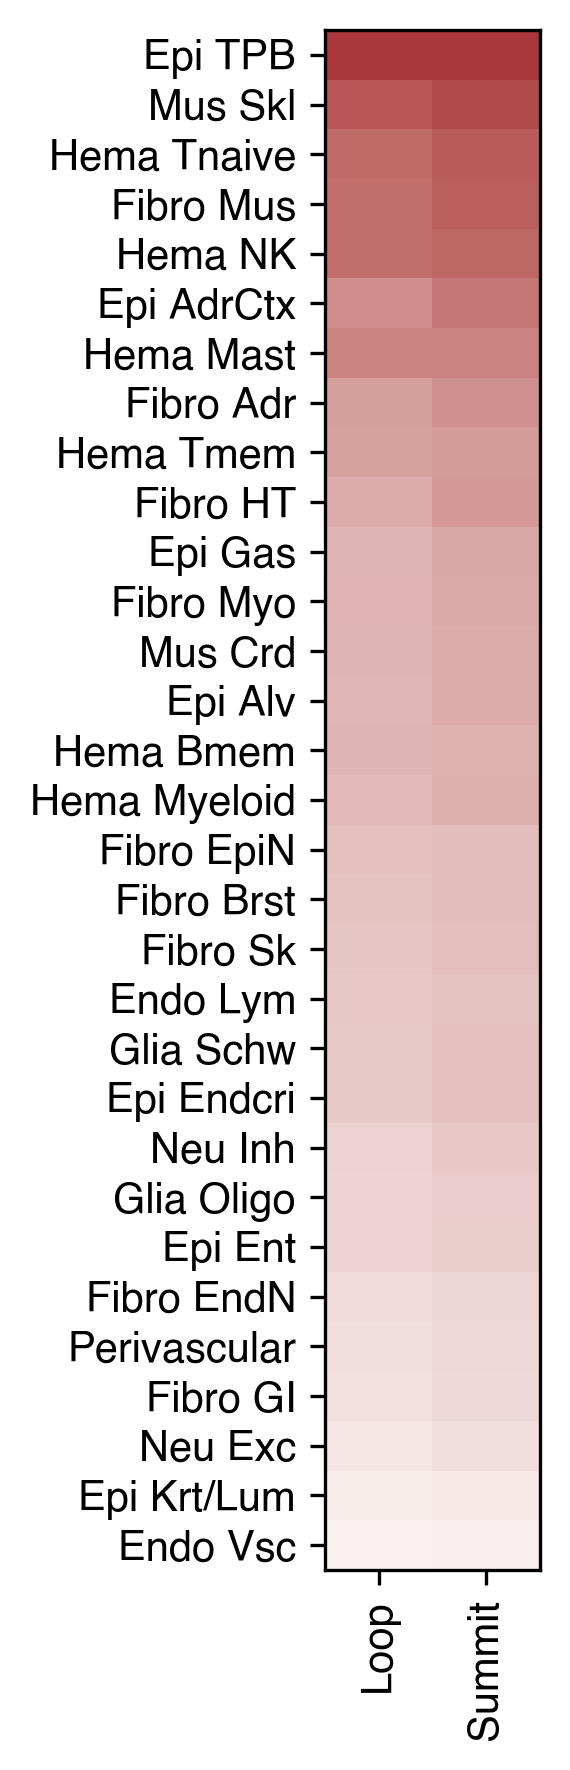

In [8]:
rorder = data[['loopodd', 'summitodd']].mean(axis=1).sort_values().index[::-1]
fig, ax = plt.subplots(figsize=(2,6), dpi=300)
ax.imshow(np.log2(data.loc[rorder, ['loopodd', 'summitodd']]), 
          cmap='vlag', vmax=2, vmin=-2, rasterized=True, aspect='auto', interpolation='none')
ax.set_yticks(np.arange(data.shape[0]))
ax.set_yticklabels(rorder.map(L1_annot))
ax.set_xticks([0,1])
ax.set_xticklabels(['Loop','Summit'], rotation=90)
fig.tight_layout()
fig.savefig(f'{outdir}loop_summit_subtypedmr_enrich.pdf', transparent=True)
